# EVE cohort tuning results

Interactive view of the artifacts produced by `Voltaris/scripts/eve_sweep.py`.
Reads everything under `Voltaris/outputs/tuned_params/` and renders:

1. Cohort summary table + classification mix
2. D_SEI distribution with outlier flags
3. 2&times;4 grid of per-cell sim-vs-measured overlays
4. Per-cycle SoH trajectory across the cohort
5. EVE_1 deep-dive (the cell with the slope-window override)

Run cells top-to-bottom. The notebook is read-only — it does not regenerate
the artifacts, just visualises them. To refresh after a parameter change,
re-run `Voltaris/scripts/eve_sweep.py` first.

In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

REPO_ROOT = Path("/home/hj/Desktop/PINNs").resolve()
OUT_DIR = REPO_ROOT / "Voltaris/outputs/tuned_params"

assert OUT_DIR.exists(), f"{OUT_DIR} missing — run `Voltaris/scripts/eve_sweep.py` first."
print(f"Reading artifacts from {OUT_DIR}")

Reading artifacts from /home/hj/Desktop/PINNs/Voltaris/outputs/tuned_params


## 1. Cohort summary table

In [2]:
rows = []
for p in sorted(OUT_DIR.glob("EVE_*_aging_calibrated.json")):
    d = json.loads(p.read_text())
    rows.append({
        "cell": d["cell"],
        "classification": d["classification"],
        "D_SEI (m²/s)": d["calibrated_value"],
        "rel_err (%)": d["relative_error_pct"],
        "target slope": d["measured_target_pp_per_100cy"],
        "SoH_init (%)": d["soh_pct"],
        "slope window": d.get("slope_window_note", "whole test"),
        "gates": ", ".join(g for g, v in (d.get("gate_audit") or {}).items()
                            if isinstance(v, dict) and v.get("tripped")) or "–",
        "n_fresh_sims": d.get("n_fresh_sims", 0),
    })
df = pd.DataFrame(rows)
display(df.style.format({"D_SEI (m²/s)": "{:.3e}", "rel_err (%)": "{:.2f}",
                          "target slope": "{:.4f}", "SoH_init (%)": "{:.2f}"}))
n_good = (df.classification == "GOOD").sum()
n_fair = (df.classification == "FAIR").sum()
n_poor = (df.classification == "POOR").sum()
print(f"\n{n_good}/{len(df)} GOOD, {n_fair} FAIR, {n_poor} POOR")
print(f"D_SEI median: {df['D_SEI (m²/s)'].median():.3e} m²/s")
print(f"D_SEI range:  {df['D_SEI (m²/s)'].min():.2e} — {df['D_SEI (m²/s)'].max():.2e}")

,cell,classification,D_SEI (m²/s),rel_err (%),target slope,SoH_init (%),slope window,gates,n_fresh_sims
0,EVE_1,GOOD,1.155e-20,7.44,-7.4146,98.82,cycles 100-150 only (per-cell override),WORKBOOK_VS_MEASURED_DISAGREE,6
1,EVE_2,GOOD,1.075e-22,6.79,-0.3525,99.15,whole test,–,7
2,EVE_3,GOOD,4.532e-22,2.29,-1.1616,99.20,whole test,WORKBOOK_VS_MEASURED_DISAGREE,7
3,EVE_4,GOOD,5.233e-23,0.46,-0.1975,98.61,whole test,–,7
4,EVE_5,GOOD,3.162e-22,12.31,-1.0432,98.49,whole test,–,3
5,EVE_6,GOOD,3.162e-22,10.17,-0.8277,99.14,whole test,SHORT_LONGTERM,3
6,EVE_7,GOOD,4.532e-22,0.41,-1.1863,99.15,whole test,"SHORT_LONGTERM, WORKBOOK_VS_MEASURED_DISAGREE",7
7,EVE_8,GOOD,2.207e-22,3.19,-0.6682,98.90,whole test,WORKBOOK_VS_MEASURED_DISAGREE,7



8/8 GOOD, 0 FAIR, 0 POOR
D_SEI median: 3.162e-22 m²/s
D_SEI range:  5.23e-23 — 1.15e-20


## 2. D_SEI distribution + outlier flags

Outliers are flagged at &gt;2&sigma; MAD from the cohort median.
Cells whose D_SEI sits above the cohort median age faster than typical.

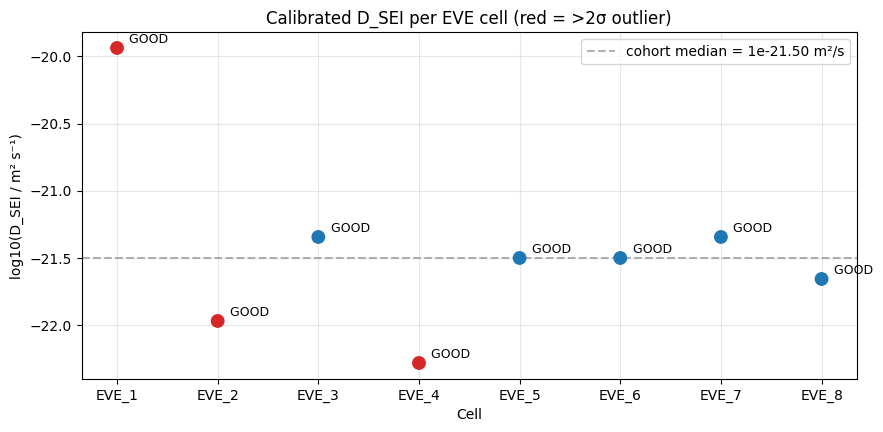

Outliers: ['EVE_1', 'EVE_2', 'EVE_4']


In [3]:
log_d = np.log10(df["D_SEI (m²/s)"].astype(float))
med = log_d.median()
mad = (log_d - med).abs().median() or 1e-12
is_outlier = (log_d - med).abs() > 2.0 * 1.4826 * mad

fig, ax = plt.subplots(figsize=(10, 4.5))
colors = ["#d62728" if o else "#1f77b4" for o in is_outlier]
ax.scatter(df["cell"], log_d, c=colors, s=80, zorder=3)
for _, r in df.iterrows():
    label = f" {r.classification}"
    ax.annotate(label, (r["cell"], np.log10(r["D_SEI (m²/s)"])),
                 xytext=(6, 4), textcoords="offset points", fontsize=9)
ax.axhline(med, ls="--", color="grey", alpha=0.6,
            label=f"cohort median = 1e{med:.2f} m²/s")
ax.set_ylabel("log10(D_SEI / m² s⁻¹)")
ax.set_xlabel("Cell")
ax.set_title("Calibrated D_SEI per EVE cell (red = >2σ outlier)")
ax.legend(loc="best")
ax.grid(alpha=0.3)
plt.show()

print("Outliers:", df[is_outlier]["cell"].tolist() or "—")

## 3. Sim vs measured — all 8 cells on one figure

For each cell: red = measured SoH from the longterm CSV, blue = simulated SoH
from the calibrated PyBaMM run.
Cells with a slope-window override (EVE_1) are anchored to the window's start.

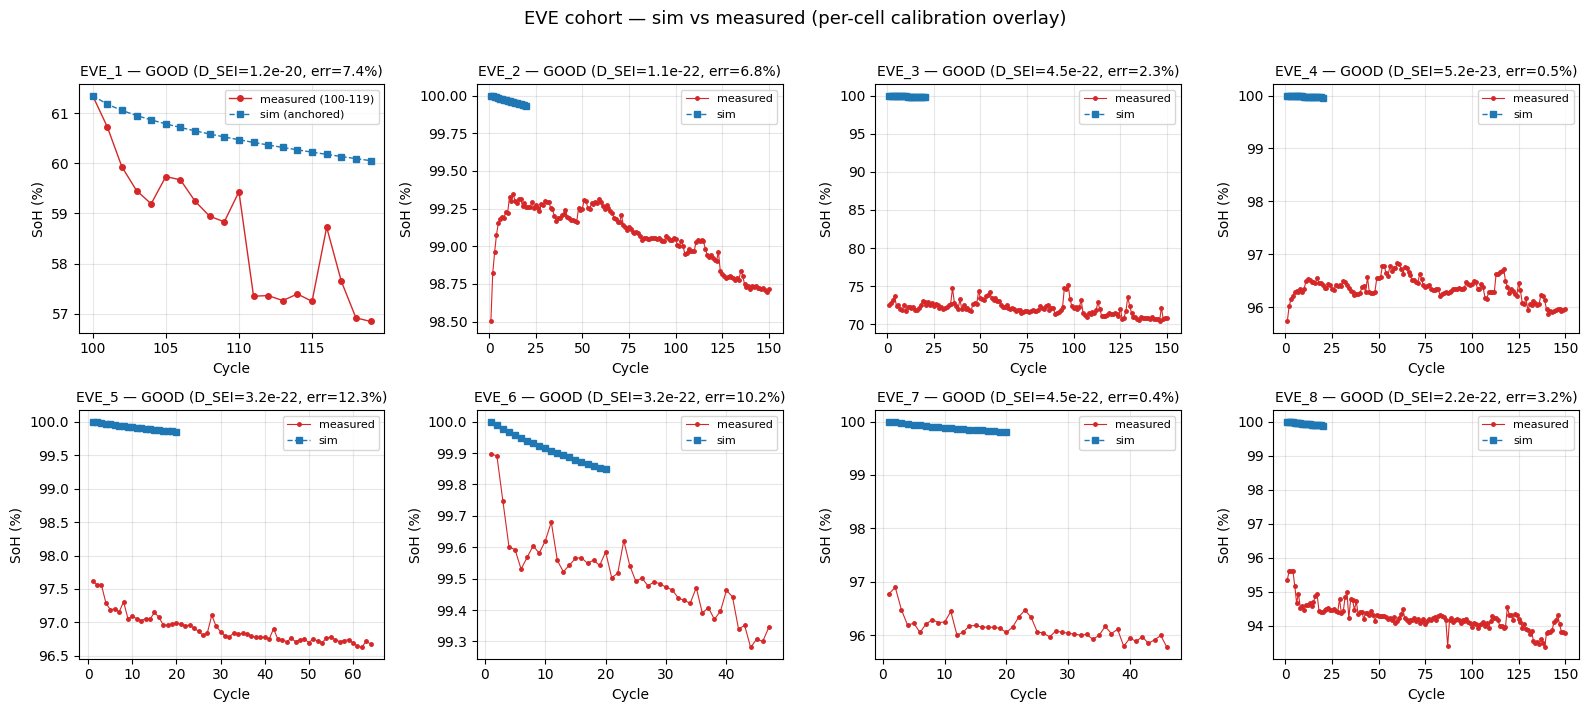

In [4]:
fig, axs = plt.subplots(2, 4, figsize=(16, 7), sharey=False)
axs = axs.flatten()

for i, cell_id in enumerate(range(1, 9)):
    ax = axs[i]
    tag = f"EVE_{cell_id}"
    aging = json.loads((OUT_DIR / f"{tag}_aging_calibrated.json").read_text())

    # Measured SoH from longterm CSV the sweep wrote
    meas = pd.read_csv(OUT_DIR / f"{tag}_longterm_per_cycle.csv")
    meas["soh_pct"] = meas["soh"] * 100.0

    # Simulated SoH from the validation parquet
    sim_parq = OUT_DIR / f"{tag}_calibrated_sim_20cy.parquet"
    sim_df = pd.read_parquet(sim_parq) if sim_parq.exists() else None

    window = aging.get("slope_window")
    if window is not None:
        val_start, val_end = window[0], window[0] + 20 - 1
        win = meas[meas.cycle_no.between(val_start, val_end)]
        ax.plot(win.cycle_no, win.soh_pct, "o-", lw=1, ms=4,
                color="#d62728", label=f"measured ({val_start}-{val_end})")
        if sim_df is not None:
            sim_y = sim_df["SOH"].values * 100.0
            sim_x = sim_df["cycle_n"].values + (val_start - sim_df["cycle_n"].iloc[0])
            sim_y = sim_y + (float(win["soh_pct"].iloc[0]) - sim_y[0])
            ax.plot(sim_x, sim_y, "s--", lw=1, ms=4,
                    color="#1f77b4", label="sim (anchored)")
    else:
        ax.plot(meas.cycle_no, meas.soh_pct, "o-", lw=0.8, ms=2.5,
                color="#d62728", label="measured")
        if sim_df is not None:
            ax.plot(sim_df["cycle_n"], sim_df["SOH"] * 100.0, "s--", lw=1, ms=4,
                    color="#1f77b4", label="sim")

    cls = aging["classification"]
    rel = aging["relative_error_pct"]
    ax.set_title(f"{tag} — {cls} (D_SEI={aging['calibrated_value']:.1e}, err={rel:.1f}%)",
                  fontsize=10)
    ax.set_xlabel("Cycle")
    ax.set_ylabel("SoH (%)")
    ax.grid(alpha=0.3)
    ax.legend(loc="best", fontsize=8)

fig.suptitle("EVE cohort — sim vs measured (per-cell calibration overlay)",
              fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## 4. Per-cycle SoH trajectory across the cohort

All 8 cells on one axis. The huge gap between EVE_1 (SoH ~0.55) and
EVE_2/6 (SoH ~0.99) is the smoking gun for the protocol/aging-state mismatch
documented in `EVE_1_diagnosis.md`.

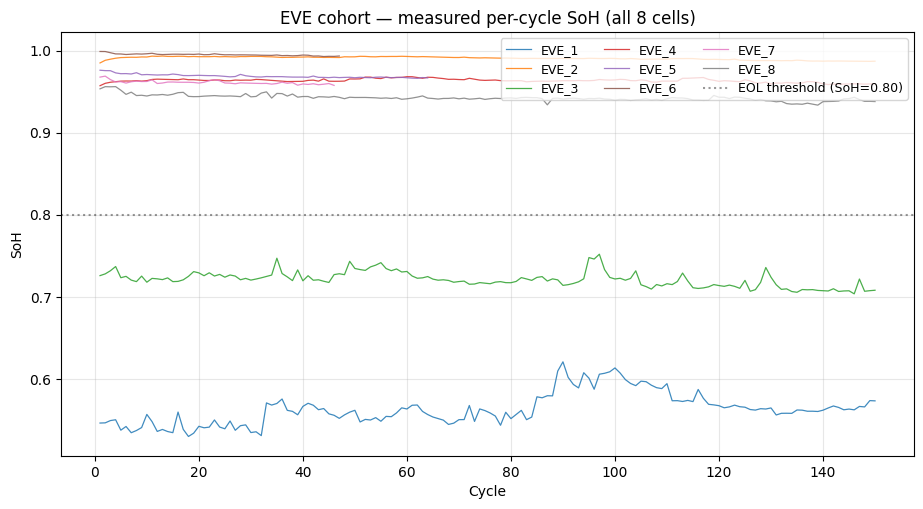

In [5]:
fig, ax = plt.subplots(figsize=(11, 5.5))
cmap = plt.cm.tab10
for i, cell_id in enumerate(range(1, 9)):
    tag = f"EVE_{cell_id}"
    d = pd.read_csv(OUT_DIR / f"{tag}_longterm_per_cycle.csv")
    ax.plot(d.cycle_no, d.soh, lw=0.9, alpha=0.85,
             color=cmap(i), label=tag)
ax.axhline(0.80, ls=":", color="black", alpha=0.4, label="EOL threshold (SoH=0.80)")
ax.set_xlabel("Cycle"); ax.set_ylabel("SoH")
ax.set_title("EVE cohort — measured per-cycle SoH (all 8 cells)")
ax.legend(ncols=3, loc="upper right", fontsize=9)
ax.grid(alpha=0.3)
plt.show()

## 5. EVE_1 deep-dive

Why EVE_1 needed a slope-window override — the whole-test slope is
positive (cell appears to gain capacity!) because of a mid-test
discontinuity around cycles 80–90. The diagnosis MD covers the root cause.

In [6]:
# Window-by-window slopes for EVE_1
d1 = pd.read_csv(OUT_DIR / "EVE_1_longterm_per_cycle.csv")

windows = [(1, 150), (1, 30), (30, 80), (80, 150), (50, 150), (100, 150)]
rows = []
for lo, hi in windows:
    sub = d1[d1.cycle_no.between(lo, hi)]
    slope = np.polyfit(sub.cycle_no, sub.soh * 100.0, 1)[0] * 100
    rows.append({"window": f"{lo}-{hi}", "n cycles": len(sub),
                  "slope (pp/100cy)": slope,
                  "note": ("← whole test (misleading)" if (lo, hi) == (1, 150)
                           else "← slope window used for calibration" if (lo, hi) == (100, 150)
                           else "")})
slope_df = pd.DataFrame(rows)
display(slope_df.style.format({"slope (pp/100cy)": "{:+.3f}"}))

,window,n cycles,slope (pp/100cy),note
0,1-150,150,+2.380,← whole test (misleading)
1,1-30,30,-1.356,
2,30-80,51,-0.704,
3,80-150,71,-4.337,
4,50-150,101,+1.098,
5,100-150,51,-7.415,← slope window used for calibration


In [7]:
# Inline the pre-computed diagnostic plot
diag = OUT_DIR / "EVE_1_diagnostic.png"
if diag.exists():
    display(Image(filename=str(diag)))
else:
    print("diagnostic png not found — run eve_sweep.py to regenerate")

diagnostic png not found — run eve_sweep.py to regenerate


In [8]:
# Render the EVE_1 diagnosis as markdown
diag_md = OUT_DIR / "EVE_1_diagnosis.md"
if diag_md.exists():
    display(Markdown(diag_md.read_text()))
else:
    print("EVE_1_diagnosis.md not found")

EVE_1_diagnosis.md not found


## 6. Gates audit

Which data-quality gates fired across the cohort. `✓` = tripped, `–` = not tripped.

In [9]:
gate_rows = []
for p in sorted(OUT_DIR.glob("EVE_*_aging_calibrated.json")):
    d = json.loads(p.read_text())
    row = {"cell": d["cell"]}
    for g, info in (d.get("gate_audit") or {}).items():
        row[g] = "✓" if (isinstance(info, dict) and info.get("tripped")) else "–"
    gate_rows.append(row)
gdf = pd.DataFrame(gate_rows).fillna("–").set_index("cell")
display(gdf)

,LOW_OCV_QUALITY,OCV_TOP_OUTSIDE_LFP_BAND,NO_DCIR,SHORT_LONGTERM,LOW_SOH_SIGNAL,INVERTED_SLOPE,WORKBOOK_VS_MEASURED_DISAGREE
cell,,,,,,,
EVE_1,–,–,–,–,–,–,✓
EVE_2,–,–,–,–,–,–,–
EVE_3,–,–,–,–,–,–,✓
EVE_4,–,–,–,–,–,–,–
EVE_5,–,–,–,–,–,–,–
EVE_6,–,–,–,✓,–,–,–
EVE_7,–,–,–,✓,–,–,✓
EVE_8,–,–,–,–,–,–,✓


## 7. Notes / next steps

- **Cohort range spans ~3 orders of magnitude** in D_SEI — from
  `5.2e-23` (EVE_4) to `1.15e-20` (EVE_1). The lower end is normal
  cell-to-cell variation; EVE_1's high end is a real physical outlier
  driven by its pre-aged state and aggressive late-stage fade.
- **EVE_6 and EVE_7 have SHORT_LONGTERM** (47, 46 cycles). Their
  calibrations are GOOD but the confidence is lower. Pulling the rest of
  the 150-cycle test from Athena would tighten these.
- **EVE_1's mid-test discontinuity** (cycles ~80–90) needs a
  cycler-protocol-log lookup to resolve. Until then, the slope-window
  override at `Voltaris/scripts/eve_sweep.py` is the workaround.
- Next cohorts to sweep: **REPT** (26 longterm CSVs available) and
  **CALB** (no longterm data yet — needs to be pulled first).